In [18]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error
import xgboost as xgb
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
from hyperopt.pyll.base import scope


df = pd.read_csv("/Users/armando/Progra/frc/predictor/second_iteration/clean_data.csv")

In [41]:
from sklearn.model_selection import train_test_split

x = df.drop(columns=['red_score', 'blue_score'])
y_general = df[['red_score', 'blue_score']]

x_train, x_test, y_gen_train, y_gen_test = train_test_split(x, y_general, test_size=0.2, random_state=8)

y_red = y_general['red_score']
y_blue = y_general['blue_score']
# _, _, y_blue_train, y_blue_test = train_test_split(x, y_blue, test_size=0.2, random_state=8)


In [46]:
print(y_blue.head(), "\n\n")
print(y_red.head())


0    143
1    149
2     37
3     97
4    126
Name: blue_score, dtype: int64 


0    124
1    144
2    129
3    118
4     67
Name: red_score, dtype: int64


In [20]:
space = {
    'max_depth':        scope.int(hp.quniform("max_depth", 1, 5, 1)),
    'gamma':            hp.uniform('gamma', 0, 1),
    'reg_alpha':        hp.uniform('reg_alpha', 0, 50),
    'reg_lambda':       hp.uniform('reg_lambda', 10, 100),
    'colsample_bytree': hp.uniform('colsample_bytree', 0, 1),
    'min_child_weight': hp.uniform('min_child_weight', 0, 5),
    'n_estimators':     10000,
    'learning_rate':    hp.uniform('learning_rate', 0, 0.15),
    'tree_method':      'hist',
    'random_state':     5,
    'max_bin':          scope.int(hp.quniform('max_bin', 200, 550, 1))
}


In [21]:
def obj_red(params):
    model = xgb.XGBRegressor(**params, eval_metric="rmse", early_stopping_rounds=50, device='cpu' )
    model.fit(x_train, y_red_train,
              eval_set=[[x_test, y_red_test]],
              verbose=False
              )
    
    preds = model.predict(x_test)
    mse = mean_squared_error(y_red_test, preds)
    
    return {"loss": mse, "status": STATUS_OK, "model": model}

In [ ]:
def obj_blue(params):
    model = xgb.XGBRegressor(**params, eval_metric="rmse", early_stopping_rounds=50, device='cpu' )
    model.fit(x_train, y_blue_train,
              eval_set=[[x_test, y_blue_test]],
              verbose=False
              )
    
    preds = model.predict(x_test)
    mse = mean_squared_error(y_blue_test, preds)
    
    return {"loss": mse, "status": STATUS_OK, "model": model}

In [23]:

trials_red = Trials()
best_red=fmin(
    fn=obj_red,
    space=space,
    algo=tpe.suggest,
    max_evals=50,
    trials=trials_red,
    rstate=np.random.default_rng(8)
)

print("Scores:", best_red)

100%|██████████| 50/50 [01:23<00:00,  1.67s/trial, best loss: 1274.4014892578125]
Scores: {'colsample_bytree': 0.08536165231934154, 'gamma': 0.24176154431553676, 'learning_rate': 0.01902327340538444, 'max_bin': 460.0, 'max_depth': 5.0, 'min_child_weight': 0.6773766476946674, 'reg_alpha': 22.394416025424142, 'reg_lambda': 16.55839334526555}


In [24]:
trials_blue = Trials()
best_blue=fmin(
    fn=obj_blue,
    space=space,
    algo=tpe.suggest,
    max_evals=50,
    trials=trials_blue,
    rstate=np.random.default_rng(8)
)

print("Scores:", best_blue)

100%|██████████| 50/50 [00:47<00:00,  1.06trial/s, best loss: 439.1205139160156] 
Scores: {'colsample_bytree': 0.9987838184274525, 'gamma': 0.2373160915389639, 'learning_rate': 0.08063690274667382, 'max_bin': 383.0, 'max_depth': 1.0, 'min_child_weight': 2.5755095161390913, 'reg_alpha': 21.16611549555486, 'reg_lambda': 19.41170623734939}


In [25]:
# Red score final
X_full_red = np.vstack([x_train, x_test])
y_full_red = np.hstack([y_red_train, y_red_test])

params_red = {
    'max_depth':        int(best_red['max_depth']),
    'gamma':            best_red['gamma'],
    'reg_alpha':        best_red['reg_alpha'],
    'reg_lambda':       best_red['reg_lambda'],
    'colsample_bytree': best_red['colsample_bytree'],
    'min_child_weight': best_red['min_child_weight'],
    'n_estimators':     10000,
    'learning_rate':    best_red['learning_rate'],
    'tree_method':      'hist',
    'random_state':     5,
    'max_bin':          int(best_red['max_bin']),
}

final_red = xgb.XGBRegressor(**params_red, eval_metric="rmse")
final_red.fit(X_full_red, y_full_red, verbose=True)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.08536165231934154, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric='rmse', feature_types=None, feature_weights=None,
             gamma=0.24176154431553676, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.01902327340538444,
             max_bin=460, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=0.6773766476946674, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=10000,
             n_jobs=None, num_parallel_tree=None, ...)

In [26]:
# blue score final
X_full_blue = np.vstack([x_train, x_test])
y_full_blue = np.hstack([y_blue_train, y_blue_test])

params_blue = {
    'max_depth':        int(best_blue['max_depth']),
    'gamma':            best_blue['gamma'],
    'reg_alpha':        best_blue['reg_alpha'],
    'reg_lambda':       best_blue['reg_lambda'],
    'colsample_bytree': best_blue['colsample_bytree'],
    'min_child_weight': best_blue['min_child_weight'],
    'n_estimators':     10000,
    'learning_rate':    best_blue['learning_rate'],
    'tree_method':      'hist',
    'random_state':     5,
    'max_bin':          int(best_blue['max_bin']),
}

final_blue = xgb.XGBRegressor(**params_blue, eval_metric="rmse")
final_blue.fit(X_full_blue, y_full_blue, verbose=True)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9987838184274525, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric='rmse', feature_types=None, feature_weights=None,
             gamma=0.2373160915389639, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.08063690274667382,
             max_bin=383, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=1, max_leaves=None,
             min_child_weight=2.5755095161390913, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=10000,
             n_jobs=None, num_parallel_tree=None, ...)

In [27]:
from sklearn.metrics import mean_squared_error

pred_red_test = final_red.predict(x_test)
print("MSE red_score (test):", mean_squared_error(y_red_test, pred_red_test))

# Y lo mismo para blue_score


MSE red_score (test): 138.79556274414062


In [28]:
pred_blue_test = final_blue.predict(x_test)
print("MSE blue_score (test):", mean_squared_error(y_blue_test, pred_blue_test))


MSE blue_score (test): 374.7464599609375


In [31]:
def inference(row):
    data = x_test.iloc[[row]]
    real_red_result = y_red_test.iloc[[row]]
    real_blue_result = y_blue_test.iloc[[row]]
    
    pred_blue = final_blue.predict(data)[0]
    pred_red = final_red.predict(data)[0]
    
    winner_pred = "red" if int(pred_red) > int(pred_blue) else "blue"
    winner_real = "red" if real_red_result.item() > real_blue_result.item() else "blue"
    winner_correct = "CORRECT!!" if winner_real == winner_pred else "WRONG ;("
    print(winner_correct)
    print(f"Real result:\nRed   Blue\n{real_red_result.item()}   {real_blue_result.item()}")
    print(f"Predicted result:\nRed   Blue\n{int(pred_red)}   {int(pred_blue)}\n\n{'- '*10}\n")
    
    return winner_real == winner_pred
    
count = 0
LENGTH = 1613
for i in range(10, 20):
    predd = inference(i)
    if predd:
        count += 1

# print((count/LENGTH)*100)


CORRECT!!
Real result:
Red   Blue
44   25
Predicted result:
Red   Blue
47   30

- - - - - - - - - - 

CORRECT!!
Real result:
Red   Blue
70   110
Predicted result:
Red   Blue
70   108

- - - - - - - - - - 

WRONG ;(
Real result:
Red   Blue
122   114
Predicted result:
Red   Blue
119   132

- - - - - - - - - - 

CORRECT!!
Real result:
Red   Blue
53   82
Predicted result:
Red   Blue
53   71

- - - - - - - - - - 

WRONG ;(
Real result:
Red   Blue
59   54
Predicted result:
Red   Blue
54   61

- - - - - - - - - - 

CORRECT!!
Real result:
Red   Blue
98   67
Predicted result:
Red   Blue
99   74

- - - - - - - - - - 

CORRECT!!
Real result:
Red   Blue
109   95
Predicted result:
Red   Blue
106   99

- - - - - - - - - - 

CORRECT!!
Real result:
Red   Blue
114   44
Predicted result:
Red   Blue
108   45

- - - - - - - - - - 

CORRECT!!
Real result:
Red   Blue
102   37
Predicted result:
Red   Blue
95   30

- - - - - - - - - - 

CORRECT!!
Real result:
Red   Blue
148   102
Predicted result:
Red   Blue


In [40]:
bst = final_red.get_booster()
# bst.dump_model("/Users/armando/Progra/frc/predictor/xgboost/red_dump.raw.txt", "/Users/armando/Progra/frc/predictor/xgboost/red_feature_map.txt")
print(bst.feature_names)

None


<Axes: >

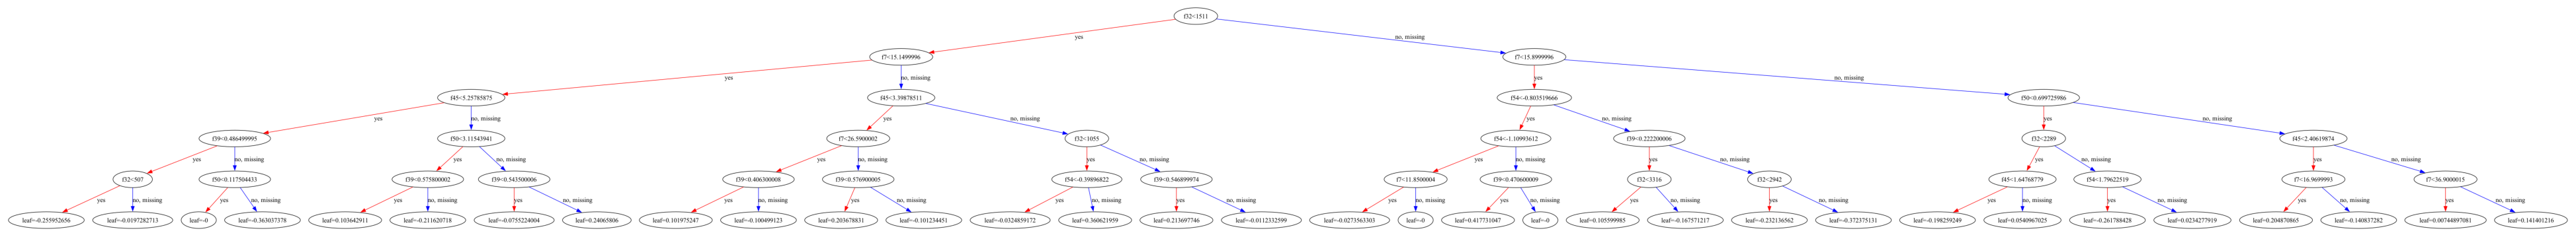

In [34]:
from xgboost import plot_tree
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(50, 50))
plot_tree(final_red, ax=ax)